# Paradoja de Simpson

## ¿Qué es la paradoja de Simpson?

La paradoja de Simpson ocurre cuando una relación que observamos en los datos agregados cambia, se debilita o incluso se invierte al separar los datos por grupos.

En otras palabras:

- A nivel general parece ocurrir una cosa
- Pero al analizar subgrupos aparece otra conclusión

Esto sucede porque existe una **variable de confusión** o una **variable de agrupación** que está influyendo en la relación entre las variables principales.

---

## Idea intuitiva

Supongamos que queremos estudiar la relación entre una variable $X$ y una variable $Y$.

Si analizamos todo junto, podríamos encontrar una tendencia como:

$$
X \uparrow \Rightarrow Y \uparrow
$$

Pero si dividimos los datos por una tercera variable, por ejemplo grupos $G$, podríamos descubrir que dentro de cada grupo la relación es distinta:

$$
X \uparrow \Rightarrow Y \downarrow
$$

Entonces la conclusión global puede ser engañosa.

---

## ¿Por qué ocurre?

La paradoja de Simpson aparece cuando:

1. Existe una tercera variable que divide naturalmente los datos
2. Esa variable afecta tanto a $X$ como a $Y$
3. Al mezclar todos los grupos, se pierde la estructura real de los datos

---

## Ejemplo conceptual

Supongamos que analizamos el peso de pingüinos en función del largo de la aleta.

Si juntamos todos los pingüinos, puede parecer que existe una relación fuerte entre longitud de aleta y peso.

Pero si los datos están repartidos entre distintas islas, y cada isla tiene especies diferentes o distribuciones distintas, entonces la isla puede estar alterando la relación observada.

En ese caso, la variable `island` puede actuar como una variable de agrupación o confusión.

---

## ¿Cómo detectar la paradoja de Simpson?

Algunas señales comunes:

- La relación global cambia al separar por grupos
- El signo de una correlación o coeficiente cambia
- El efecto de una variable parece fuerte globalmente, pero disminuye o cambia dentro de subgrupos
- Los grupos tienen tamaños o composiciones diferentes

---

## ¿Cómo evitar este problema?

Para evitar conclusiones incorrectas, se recomienda:

1. No analizar solo los datos agregados
2. Revisar si existen variables categóricas importantes como:
   - isla
   - especie
   - sexo
   - grupo etario
3. Comparar el análisis global con el análisis por subgrupos
4. Incluir la variable de agrupación en el modelo


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
penguins_df = sns.load_dataset('penguins').dropna()
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

penguin_color = {
    'Adelie': '#ff6602ff',
    'Gentoo': '#0f7175ff',
    'Chinstrap': '#c65dc9ff'
}

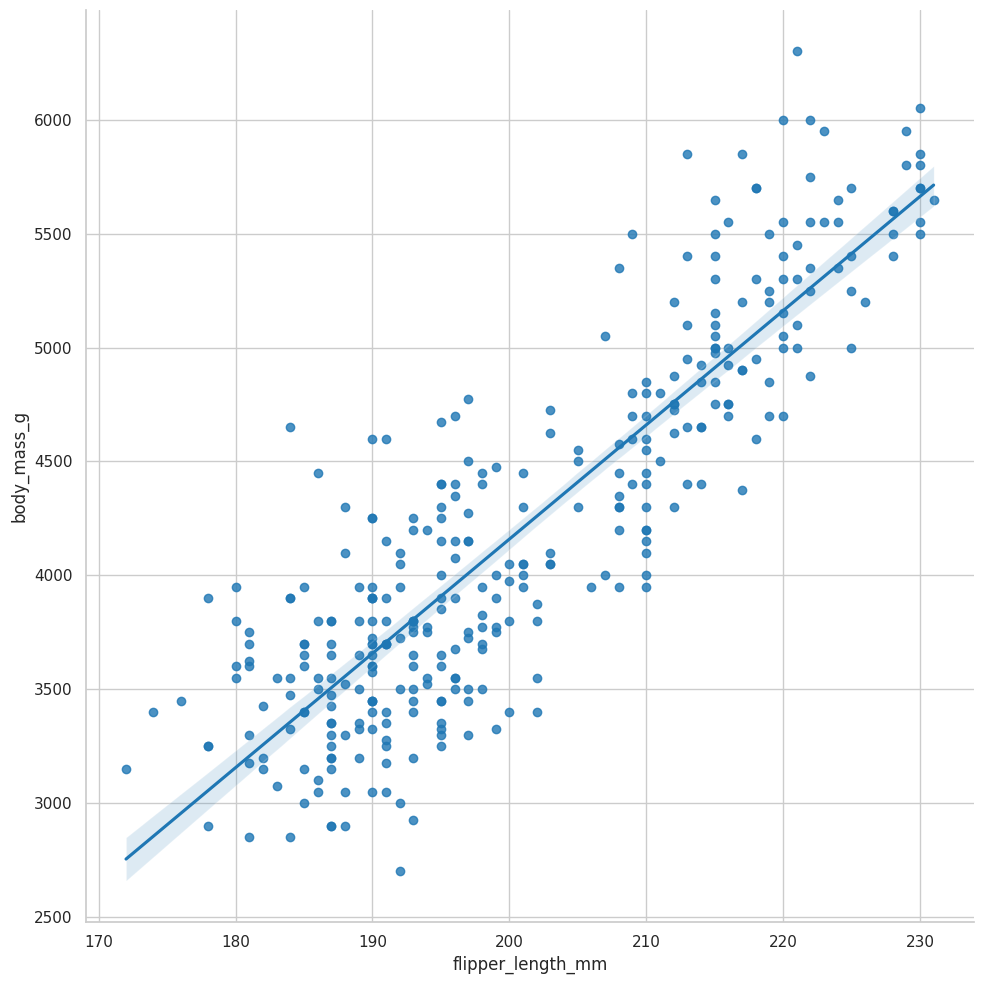

In [5]:
sns.lmplot(
    data=penguins_df,
    x='flipper_length_mm',
    y='body_mass_g',
    height=10,
    palette=penguin_color
)

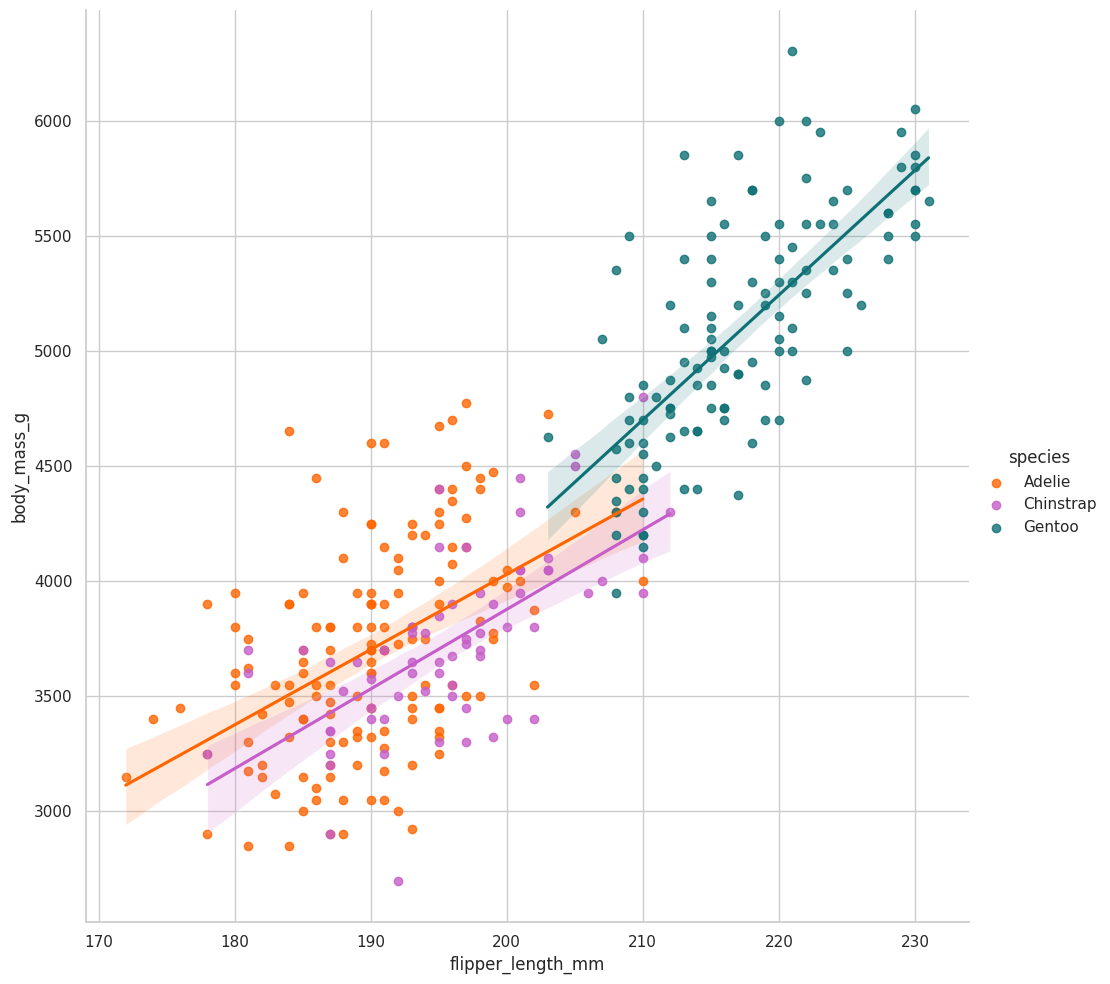

In [6]:
sns.lmplot(
    data=penguins_df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    height=10,
    palette=penguin_color
)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

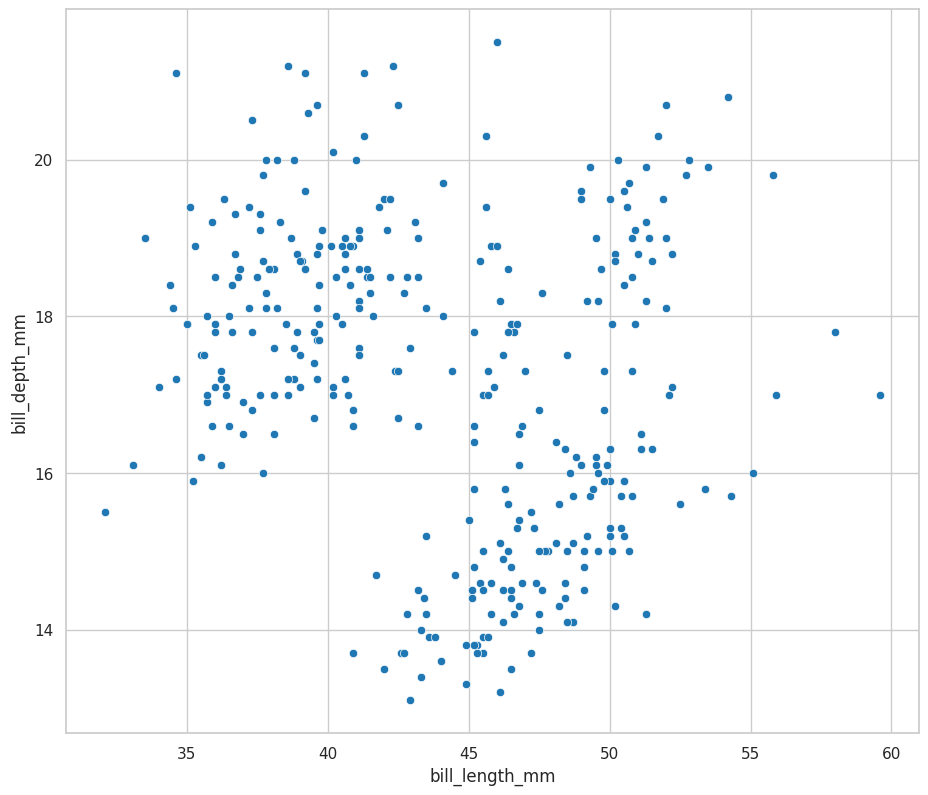

In [7]:
sns.scatterplot(
    data=penguins_df,
    x='bill_length_mm',
    y='bill_depth_mm'
)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

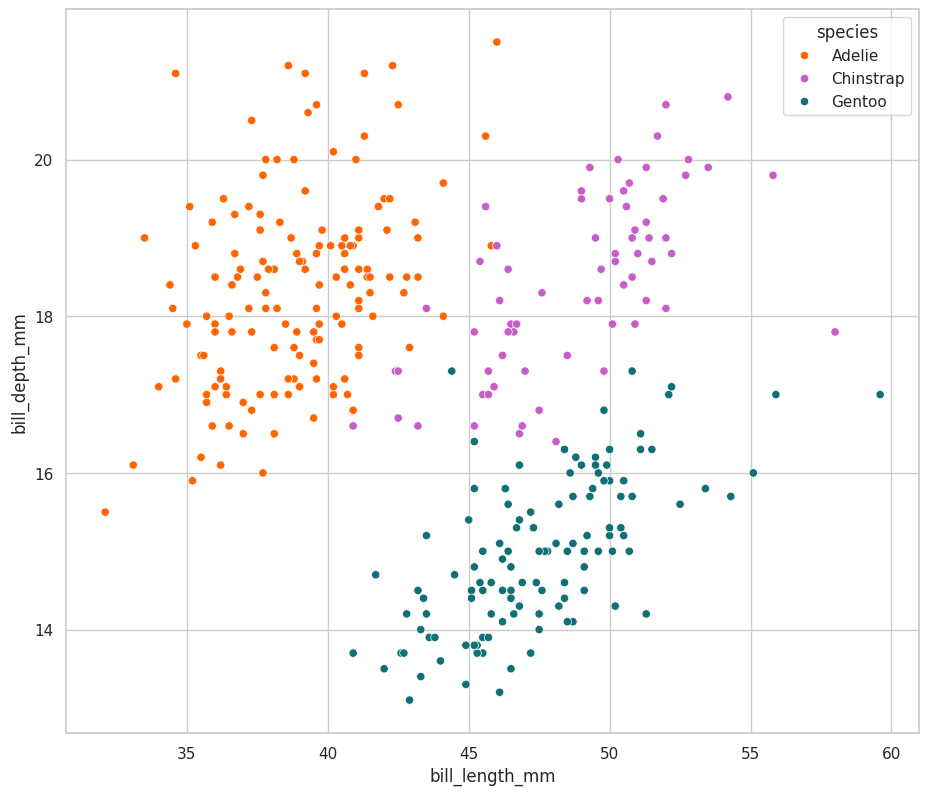

In [8]:
sns.scatterplot(
    data=penguins_df,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    palette=penguin_color
)

## APLICAMOS LA REGRESIÓN LINEAL MULTIPLE AGRUPANDOLA POR SPECIES

Regresión lineal del dataset completo:
                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1060.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          3.13e-105
Time:                        03:42:02   Log-Likelihood:                -2461.1
No. Observations:                 333   AIC:                             4926.
Df Residuals:                     331   BIC:                             4934.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

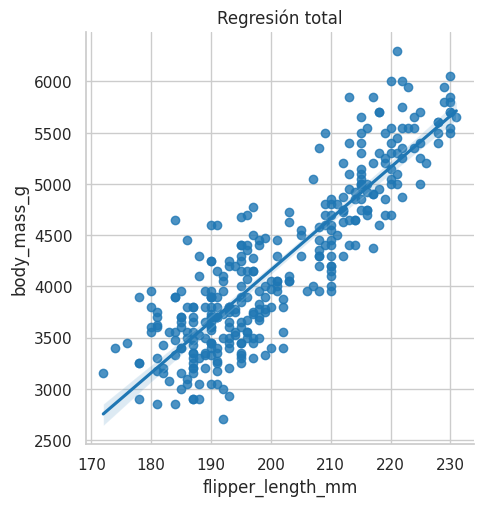

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

modelo_total = smf.ols("body_mass_g ~ flipper_length_mm",data=penguins_df).fit()
print("Regresión lineal del dataset completo:")
print(modelo_total.summary())

sns.lmplot(x='flipper_length_mm',y='body_mass_g',data=penguins_df)
plt.title('Regresión total')
plt.show()

# REGRESIÓN LINEAL PARCIAL

Regresión lineal para Adelie
                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     39.69
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.40e-09
Time:                        03:42:36   Log-Likelihood:                -1083.6
No. Observations:                 146   AIC:                             2171.
Df Residuals:                     144   BIC:                             2177.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept

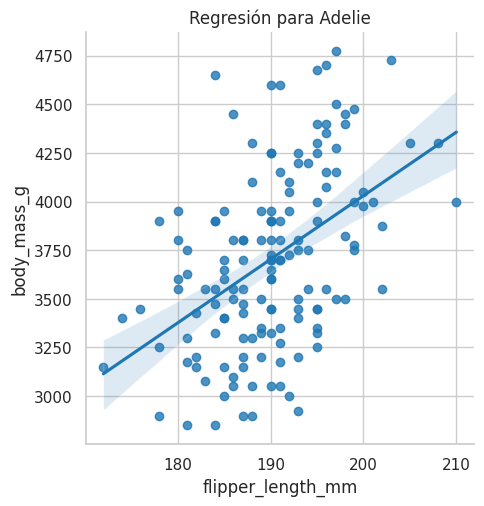

Regresión lineal para Chinstrap
                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     46.17
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           3.75e-09
Time:                        03:42:37   Log-Likelihood:                -482.66
No. Observations:                  68   AIC:                             969.3
Df Residuals:                      66   BIC:                             973.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Interc

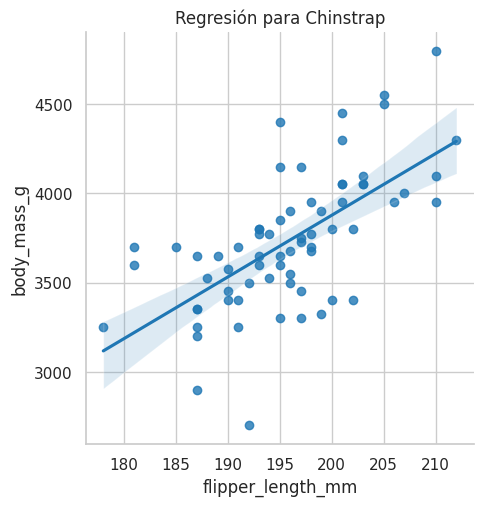

Regresión lineal para Gentoo
                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     119.8
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.25e-19
Time:                        03:42:37   Log-Likelihood:                -866.29
No. Observations:                 119   AIC:                             1737.
Df Residuals:                     117   BIC:                             1742.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept

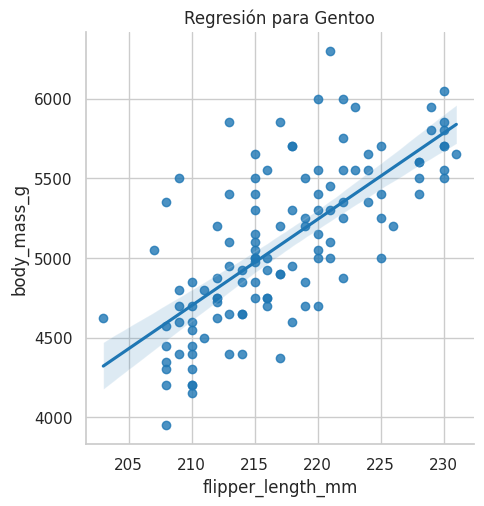

In [10]:
#modelo parcial por species
species_models = {}
for species,df in penguins_df.groupby('species'):
  model = smf.ols("body_mass_g ~ flipper_length_mm",data=df).fit()
  species_models[species] = model
  print(f'Regresión lineal para {species}')
  print(model.summary())
  sns.lmplot(x='flipper_length_mm',y='body_mass_g',data=df)
  plt.title(f'Regresión para {species}')
  plt.show()